# Step 3 (working through the data)

Another adaptation from the suite2p notebooks that loads your data after running and curating suite2p results


In [5]:
from pathlib import Path
from tempfile import TemporaryDirectory
import scipy.stats as scistat

import matplotlib.pyplot as plt
import suite2p
import matplotlib as mpl
import numpy as np

# Figure Style settings for notebook.
'''
mpl.rcParams.update({
    'axes.spines.left': False,
    'axes.spines.bottom': False,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'legend.frameon': False,
    'figure.subplot.wspace': .01,
    'figure.subplot.hspace': .01,
    'figure.figsize': (18, 13),
    'ytick.major.left': False,
})
'''
#jet = plt.cm.get_cmap('Spectral')
#jet.set_bad(color='k')

"\nmpl.rcParams.update({\n    'axes.spines.left': False,\n    'axes.spines.bottom': False,\n    'axes.spines.top': False,\n    'axes.spines.right': False,\n    'legend.frameon': False,\n    'figure.subplot.wspace': .01,\n    'figure.subplot.hspace': .01,\n    'figure.figsize': (18, 13),\n    'ytick.major.left': False,\n})\n"

In [6]:
import os; import matplotlib.pyplot as plt; import tifffile as tf
path_added = os.path.split(os.path.split(os.getcwd())[0])[0]; os.chdir(path_added); print("Added path:",path_added)
import nwbfun as nwbfun
import s2pfuns
import matplotlib.pyplot as plt

Added path: c:\Users\johnj\SpellmanLab Dropbox\timspellman\Python\John\PySpell\code


Load in the NWB file

In [42]:
fname = r"C:\Users\johnj\SpellmanLab Dropbox\OtherData\John\ProjectData\L6_IMGDRIVE_DATA\LAYER6\L6Chrimson_PanneuronalRec\L602\SD1_whisker_d7.nwb"
stat, ops, F, Fneu, spks, iscell, probcell, redcell, probredcell = nwbfun.suite2p_nwb().read_nwb(fpath=fname)

# filter data
blF = s2pfuns.baseline_corrected_F(F=F,Fneu=Fneu,ops=ops)[iscell]
spks = spks[iscell]
F = F[iscell]

cell_idx = np.linspace(0,len(iscell),len(iscell), dtype=int)
iscell_idx = cell_idx[iscell]

c:\Users\johnj\anaconda3\envs\spellPy\lib\site-packages\hdmf\utils.py:668: UserWarning: Ignoring cached namespace 'core' version 2.6.0-alpha because version 2.7.0 is already loaded.
  return func(args[0], **pargs)


Plot

In [10]:
print("Number of cells: ",F.shape[0])

Number of cells:  163


In [8]:
%matplotlib tk

im = suite2p.ROI.stats_dicts_to_3d_array(stat, Ly=ops['Ly'], Lx=ops['Lx'], label_id=True)
im[im == 0] = np.nan

plt.subplot(1, 4, 1)
plt.imshow(ops['max_proj'], cmap='gray')
plt.title("Registered Image, Max Projection")

plt.subplot(1, 4, 2)
plt.imshow(np.nanmax(im, axis=0), cmap='jet')
plt.title("All ROIs Found")

plt.subplot(1, 4, 3)
plt.imshow(np.nanmax(im[~iscell], axis=0, ), cmap='jet')
plt.title("All Non-Cell ROIs")

plt.subplot(1, 4, 4)
plt.imshow(np.nanmax(im[iscell], axis=0), cmap='jet')
plt.title("All Cell ROIs");

C:\Users\johnj\AppData\Local\Temp\ipykernel_17936\3240414702.py:11: RuntimeWarning: All-NaN slice encountered
  plt.imshow(np.nanmax(im, axis=0), cmap='jet')
C:\Users\johnj\AppData\Local\Temp\ipykernel_17936\3240414702.py:15: RuntimeWarning: All-NaN slice encountered
  plt.imshow(np.nanmax(im[~iscell], axis=0, ), cmap='jet')
C:\Users\johnj\AppData\Local\Temp\ipykernel_17936\3240414702.py:19: RuntimeWarning: All-NaN slice encountered
  plt.imshow(np.nanmax(im[iscell], axis=0), cmap='jet')


In [11]:
stat[iscell][0].keys()

dict_keys(['ypix', 'xpix', 'lam', 'med', 'mrs', 'mrs0', 'compact', 'solidity', 'npix', 'npix_soma', 'soma_crop', 'overlap', 'radius', 'aspect_ratio', 'npix_norm_no_crop', 'npix_norm', 'footprint', 'skew'])

## Visualizations

Filter out cells. How to find cellID

In [12]:
comp = 4
fig = plt.figure()
plt.imshow(im[iscell][comp][0:1000])

fig2 = plt.figure()
plt.plot(F[comp][0:1000])

In [46]:
looper = 10
#iscell_idx = cell_idx[iscell]
fig, ax = plt.subplots(nrows = int(spks.shape[0]/looper), ncols = 1)
plt.tight_layout()
#plt.subplots_adjust(hspace=0.25)
xlabel = np.linspace(0, (2000/(30/4)), 2000)
counter = 0
for celli in range(0, spks.shape[0], looper):
    ax[counter].plot(xlabel, scistat.zscore(blF[celli][0:2000]),color='k') 
    ax[counter].plot(xlabel, scistat.zscore(spks[celli][0:2000]),color='r',linewidth=.5)
    ax[counter].axis('off')
    ax[counter].set_title(iscell_idx[celli])
    
    counter += 1
ax[counter-1].set_xlabel("Time (sec)")

C:\Users\johnj\AppData\Local\Temp\ipykernel_17936\995436749.py:4: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


IndexError: index 16 is out of bounds for axis 0 with size 16

In [36]:
(2000/(30/4))

266.6666666666667

In [13]:

plt.figure(figsize=[20,20])
plt.suptitle("Flourescence and Deconvolved Traces for Different ROIs", y=0.92);
rois = np.arange(len(f_cells))[::20]
for i, roi in enumerate(rois):
    plt.subplot(len(rois), 1, i+1, )
    f = f_cells[roi]
    f_neu = f_neuropils[roi]
    sp = spks[roi]
    # Adjust spks range to match range of fluroescence traces
    fmax = np.maximum(f.max(), f_neu.max())
    fmin = np.minimum(f.min(), f_neu.min())
    frange = fmax - fmin 
    sp /= sp.max()
    sp *= frange
    plt.plot(f, label="Cell Fluorescence")
    plt.plot(f_neu, label="Neuropil Fluorescence")
    plt.plot(sp + fmin, label="Deconvolved")
    plt.xticks(np.arange(0, f_cells.shape[1], f_cells.shape[1]/10))
    plt.ylabel(f"ROI {roi}", rotation=0)
    plt.xlabel("frame")
    if i == 0:
        plt.legend(bbox_to_anchor=(0.93, 2))

NameError: name 'f_cells' is not defined

### Registration

Text(0.5, 1.0, 'Mean registered image')

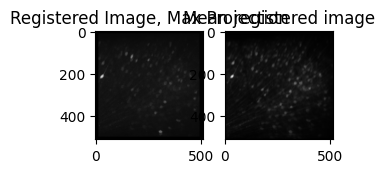

In [12]:
plt.subplot(1, 4, 2)
plt.imshow(ops['max_proj'], cmap='gray')
plt.title("Registered Image, Max Projection")

plt.subplot(1, 4, 3)
plt.imshow(ops['meanImg'], cmap='gray')
plt.title("Mean registered image")

### Detection


The `cell_roi` variable is a matrix with different numerical values set for different components so that we can distinguish them. For the purposes of this visualization, set them to all be one value

C:\Users\johnj\AppData\Local\Temp\ipykernel_38832\2819684976.py:1: RuntimeWarning: All-NaN slice encountered
  cell_roi = np.nanmax(im[iscell], axis=0)


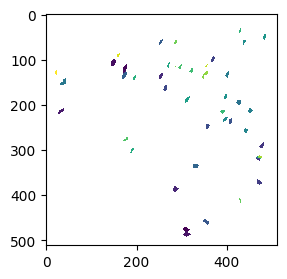

In [14]:
cell_roi = np.nanmax(im[iscell], axis=0)
plt.figure(figsize=(3,3))
plt.imshow(cell_roi)

## Extract Traces


In [17]:
f_cells = np.load(Path(ops['save_path']).joinpath('F.npy'))
f_neuropils = np.load(Path(ops['save_path']).joinpath('Fneu.npy'))
spks = np.load(Path(ops['save_path']).joinpath('spks.npy'))
f_cells.shape, f_neuropils.shape, spks.shape

((103, 6000), (103, 6000), (103, 6000))